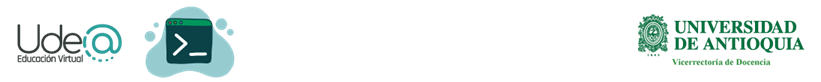

# <h1><center>Kernel Principal Component Analysis</center></h1>

**Especialización en Analítica de Datos**

*Prof. Hernán Felipe García Arias*

*Facultad de Ingeniería*

*Universidad de Antioquia*


**2025-1**


**Review**

1.1. Principal Component Analysis

Principal component analysis, or PCA, is a very popular technique for dimensionality reduction and feature extraction. PCA attempts to find a linear subspace of lower dimensionality than the original feature space, where the new features have the largest variance (Bishop, 2006).

Consider a dataset $\left\{\mathbf{x}_i\right\}$ where $i=1,2, \cdots, N$, and each $\mathbf{x}_i$ is a $D$-dimensional vector. Now we want to project the data onto an $M$-dimensional subspace, where $M<D$. We assume the projection is denoted as $\mathbf{y}=\mathbf{A x}$, where $\mathbf{A}=\left[\mathbf{u}_1^{\mathrm{T}}, \cdots, \mathbf{u}_M^{\mathrm{T}}\right]$, and $\mathbf{u}_k^{\mathrm{T}} \mathbf{u}_k=1$ for $k=1,2, \cdots, M$. We want to maximize the variance of $\left\{\mathbf{y}_i\right\}$, which is the trace of the covariance matrix of $\left\{\mathbf{y}_i\right\}$.

**Constructing the Kernel Matrix**

Assume we have a nonlinear transformation $\phi(\mathbf{x})$ from the original $D$-dimensional feature space to an $M$ dimensional feature space, where usually $M \gg D$. Then each data point $\mathbf{x}_i$ is projected to a point $\phi\left(\mathbf{x}_i\right)$. We can perform standard PCA in the new feature space, but this can be extremely costly and inefficient. Fortunately, we can use kernel methods to simplify the computation (Schölkopf et al., 1998).

First, we assume that the projected new features have zero mean: $\square$

$$
\frac{1}{N} \sum_{i=1}^N \phi\left(\mathbf{x}_i\right)=\mathbf{0}
$$


The covariance matrix of the projected features is $M \times$ $M$, calculated by

$$
\mathbf{C}=\frac{1}{N} \sum_{i=1}^N \phi\left(\mathbf{x}_i\right) \phi\left(\mathbf{x}_i\right)^{\mathrm{T}}
$$


Its eigenvalues and eigenvectors are given by

$$
\mathbf{C v _ { k }}=\lambda_k \mathbf{v}_k
$$

where $k=1,2, \cdots, M$. From Eq. (17) and Eq. (18), we have

$$
\frac{1}{N} \sum_{i=1}^N \phi\left(\mathbf{x}_i\right)\left\{\phi\left(\mathbf{x}_i\right)^{\mathrm{T}} \mathbf{v}_k\right\}=\lambda_k \mathbf{v}_k
$$

which can be rewritten as


$$
\mathbf{v}_k=\sum_{i=1}^N a_{k i} \phi\left(\mathbf{x}_i\right)
$$


Now by substituting $\mathbf{v}_k$ in Eq. (19) with Eq. (20), we have

$$
\frac{1}{N} \sum_{i=1}^N \phi\left(\mathbf{x}_i\right) \phi\left(\mathbf{x}_i\right)^{\mathrm{T}} \sum_{j=1}^N a_{k j} \phi\left(\mathbf{x}_j\right)=\lambda_k \sum_{i=1}^N a_{k i} \phi\left(\mathbf{x}_i\right)
$$


If we define the kernel function

$$
\kappa\left(\mathbf{x}_i, \mathbf{x}_j\right)=\phi\left(\mathbf{x}_i\right)^{\mathrm{T}} \phi\left(\mathbf{x}_j\right)
$$


$\mathbf{y}=\mathbf{A x}$, where $\mathbf{A}=\left[\mathbf{u}_1^{\mathrm{T}}, \cdots, \mathbf{u}_M^{\mathrm{T}}\right]$, and $\mathbf{u}_k^{\mathrm{T}} \mathbf{u}_k=1$ for $k=1,2, \cdots, M$. We want to maximize the variance of $\left\{\mathbf{y}_i\right\}$, which is the trace of the covariance matrix of $\left\{\mathbf{y}_i\right\}$. Thus, we want to find

and multiply both sides of Eq. (21) by $\phi\left(\mathrm{x}_l\right)^{\mathrm{T}}$, we have

$$
\frac{1}{N} \sum_{i=1}^N \kappa\left(\mathbf{x}_l, \mathbf{x}_i\right) \sum_{j=1}^N a_{k j} \kappa\left(\mathbf{x}_i, \mathbf{x}_j\right)=\lambda_k \sum_{i=1}^N a_{k i} \kappa\left(\mathbf{x}_l, \mathbf{x}_i\right)
$$


We can use the matrix notation

$$
\mathbf{K}^2 \mathbf{a}_k=\lambda_k N \mathbf{K} \mathbf{a}_k,
$$

where

$$
\mathbf{K}_{i, j}=\kappa\left(\mathbf{x}_i, \mathbf{x}_j\right)
$$

and $\mathbf{a}_k$ is the $N$-dimensional column vector of $a_{k i}$ :

$$
\mathbf{a}_{\mathbf{k}}=\left[\begin{array}{llll}
a_{k 1} & a_{k 2} & \cdots & a_{k N}
\end{array}\right]^{\mathrm{T}}
$$

$\mathbf{a}_k$ can be solved by

$$
\mathbf{K a}_k=\lambda_k N \mathbf{a}_k,
$$

and the resulting kernel principal components can be calculated using

$$
y_k(\mathbf{x})=\phi(\mathbf{x})^{\mathrm{T}} \mathbf{v}_k=\sum_{i=1}^N a_{k i} \kappa\left(\mathbf{x}, \mathbf{x}_i\right)
$$


If the projected dataset $\left\{\phi\left(\mathbf{x}_i\right)\right\}$ does not have zero mean, we can use the Gram matrix $\widetilde{\mathbf{K}}$ to substitute the kernel matrix $\mathbf{K}$. The Gram matrix is given by

$$
\widetilde{\mathbf{K}}=\mathbf{K}-\mathbf{1}_N \mathbf{K}-\mathbf{K} \mathbf{1}_N+\mathbf{1}_N \mathbf{K} \mathbf{1}_N
$$

where $\mathbf{1}_N$ is the $N \times N$ matrix with all elements equal to $1 / N$ (Bishop, 2006).
The power of kernel methods is that we do not have to compute $\phi\left(\mathbf{x}_i\right)$ explicitly. We can directly construct the kernel matrix from the training data set $\left\{\mathbf{x}_i\right\}$ (Weinberger et al., 2004). Two commonly used kernels are the polynomial kernel


$$
\kappa(\mathbf{x}, \mathbf{y})=\left(\mathbf{x}^{\mathrm{T}} \mathbf{y}\right)^d
$$

or

$$
\kappa(\mathbf{x}, \mathbf{y})=\left(\mathbf{x}^{\mathrm{T}} \mathbf{y}+c\right)^d
$$

where $c>0$ is a constant, and the Gaussian kernel

$$
\kappa(\mathbf{x}, \mathbf{y})=\exp \left(-\|\mathbf{x}-\mathbf{y}\|^2 / 2 \sigma^2\right)
$$

with parameter $\sigma$.
The standard steps of kernel PCA dimensionality reduction can be summarized as:
1. Construct the kernel matrix $\mathbf{K}$ from the training data set $\left\{\mathbf{x}_i\right\}$ using Eq. (25).
2. Compute the Gram matrix $\widetilde{\mathbf{K}}$ using Eq. (29).
3. Use Eq. (27) to solve for the vectors $\mathbf{a}_i$ (substitute $\mathbf{K}$ with $\widetilde{\mathbf{K}}$ ).
4. Compute the kernel principal components $y_k(\mathbf{x})$ using the above equation.



# Kernel PCA


This example shows that Kernel PCA is able to find a projection of the data
that makes data linearly separable.


Automatically created module for IPython interactive environment


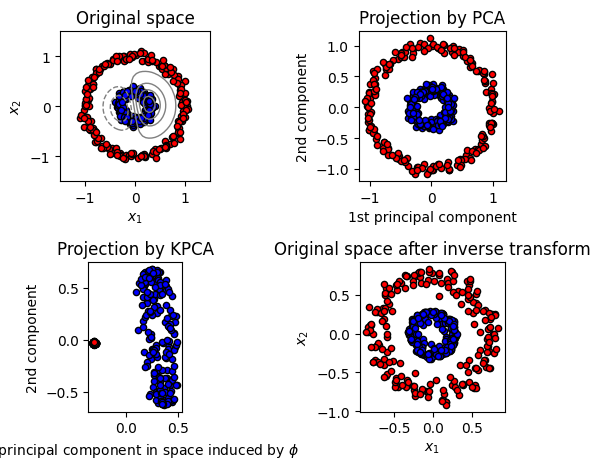

In [ ]:
print(__doc__)

# Authors: Mathieu Blondel
#          Andreas Mueller
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles

np.random.seed(0)

X, y = make_circles(n_samples=400, factor=.3, noise=.05)

kpca = KernelPCA(kernel="rbf", fit_inverse_transform=True, gamma=10)
X_kpca = kpca.fit_transform(X)
X_back = kpca.inverse_transform(X_kpca)
pca = PCA()
X_pca = pca.fit_transform(X)

# Plot results

plt.figure()
plt.subplot(2, 2, 1, aspect='equal')
plt.title("Original space")
reds = y == 0
blues = y == 1

plt.scatter(X[reds, 0], X[reds, 1], c="red",
            s=20, edgecolor='k')
plt.scatter(X[blues, 0], X[blues, 1], c="blue",
            s=20, edgecolor='k')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

X1, X2 = np.meshgrid(np.linspace(-1.5, 1.5, 50), np.linspace(-1.5, 1.5, 50))
X_grid = np.array([np.ravel(X1), np.ravel(X2)]).T
# projection on the first principal component (in the phi space)
Z_grid = kpca.transform(X_grid)[:, 0].reshape(X1.shape)
plt.contour(X1, X2, Z_grid, colors='grey', linewidths=1, origin='lower')

plt.subplot(2, 2, 2, aspect='equal')
plt.scatter(X_pca[reds, 0], X_pca[reds, 1], c="red",
            s=20, edgecolor='k')
plt.scatter(X_pca[blues, 0], X_pca[blues, 1], c="blue",
            s=20, edgecolor='k')
plt.title("Projection by PCA")
plt.xlabel("1st principal component")
plt.ylabel("2nd component")

plt.subplot(2, 2, 3, aspect='equal')
plt.scatter(X_kpca[reds, 1], X_kpca[reds, 2], c="red",
            s=20, edgecolor='k')
plt.scatter(X_kpca[blues, 1], X_kpca[blues, 2], c="blue",
            s=20, edgecolor='k')
plt.title("Projection by KPCA")
plt.xlabel(r"1st principal component in space induced by $\phi$")
plt.ylabel("2nd component")

plt.subplot(2, 2, 4, aspect='equal')
plt.scatter(X_back[reds, 0], X_back[reds, 1], c="red",
            s=20, edgecolor='k')
plt.scatter(X_back[blues, 0], X_back[blues, 1], c="blue",
            s=20, edgecolor='k')
plt.title("Original space after inverse transform")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.tight_layout()
plt.show()

**References**

 1. Wang, Q. (2012). Kernel principal component analysis and its applications in face recognition and active shape models. arXiv preprint arXiv:1207.3538.